# Preprocessing Strategy Feature Importance Consistency

This notebook investigates how different preprocessing strategies affect feature importance consistency **within** the same algorithm.

Each algorithm is compared against itself across two preprocessing strategies:
- **SMOTE** (oversampling)
- **Undersampling** (random undersampling)

Comparisons are always **same algorithm, different strategy** — never cross-algorithm:
- Logistic Regression (SMOTE) vs Logistic Regression (Undersampling)
- Random Forest (SMOTE) vs Random Forest (Undersampling)
- XGBoost (SMOTE) vs XGBoost (Undersampling)
- Decision Tree (SMOTE) vs Decision Tree (Undersampling)

**Methods used:**
- Top-10 overlap — how many of the top 10 features are shared between the two strategies
- Spearman rank correlation — how similar the full feature rankings are between strategies
- Jaccard similarity — set-based overlap of the top-10 feature lists

In [15]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})

os.makedirs("../results/figures/preprocessing_feature_consistency/", exist_ok=True)

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}
MODELS     = list(MODEL_COLORS.keys())
STRATEGIES = ["SMOTE", "Undersampling"]
TOP_N      = 10

## Loading SHAP Feature Importance Data

All feature importance CSV files are loaded and filtered to retain only SHAP results. Both preprocessing strategies (SMOTE and Undersampling) are kept, since the comparison here is **between** strategies within the same model.

In [16]:
files = glob.glob("../results/features/*_feature_importance.csv")

if not files:
    raise FileNotFoundError("No feature importance files found. Run all model notebooks first.")

raw_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Keep only SHAP results
shap_df = raw_df[raw_df["Method"] == "SHAP"].copy()

print("Models found:     ", shap_df["Model"].unique())
print("Strategies found: ", shap_df["Strategy"].unique())
print("Total rows:       ", len(shap_df))

Models found:      ['Logistic Regression' 'Decision Tree' 'XGBoost' 'Random Forest']
Strategies found:  ['Undersampling' 'SMOTE']
Total rows:        288


## Helper Functions

The same three consistency metrics used in the model-comparison notebook, now applied **across strategies within a model** instead of across models within a strategy:

- `top_n_overlap` — count of shared features in the top N
- `spearman_correlation` — Spearman rank correlation over the full feature ranking
- `jaccard_similarity` — size of intersection divided by size of union for the top N feature sets

In [17]:
def get_top_n(df, model, strategy, n=TOP_N):
    """Return the top-N feature names for a given model and strategy."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return set(subset.nsmallest(n, "Rank")["Feature"].tolist())


def get_full_ranking(df, model, strategy):
    """Return a Series of rank values indexed by feature."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return subset.set_index("Feature")["Rank"].sort_values()


def top_n_overlap(df, model, strategy_a, strategy_b, n=TOP_N):
    """Number of shared features in the top N between two preprocessing strategies."""
    top_a = get_top_n(df, model, strategy_a, n)
    top_b = get_top_n(df, model, strategy_b, n)
    return len(top_a & top_b)


def spearman_correlation(df, model, strategy_a, strategy_b):
    """Spearman rank correlation of full feature rankings between two preprocessing strategies."""
    rank_a = get_full_ranking(df, model, strategy_a)
    rank_b = get_full_ranking(df, model, strategy_b)
    common = rank_a.index.intersection(rank_b.index)
    if len(common) < 2:
        return np.nan
    corr, _ = spearmanr(rank_a[common], rank_b[common])
    return round(corr, 4)


def jaccard_similarity(df, model, strategy_a, strategy_b, n=TOP_N):
    """Jaccard similarity of top-N feature sets between two preprocessing strategies."""
    top_a = get_top_n(df, model, strategy_a, n)
    top_b = get_top_n(df, model, strategy_b, n)
    if not top_a | top_b:
        return 0.0
    return round(len(top_a & top_b) / len(top_a | top_b), 4)


def compute_all_metrics(df, models=MODELS,
                        strategy_a="SMOTE", strategy_b="Undersampling", n=TOP_N):
    """Compute all three metrics for every model and return a summary DataFrame."""
    rows = []
    for model in models:
        has_a = not df[(df["Model"] == model) & (df["Strategy"] == strategy_a)].empty
        has_b = not df[(df["Model"] == model) & (df["Strategy"] == strategy_b)].empty
        if not (has_a and has_b):
            continue
        rows.append({
            "Model":       model,
            "Strategy A":  strategy_a,
            "Strategy B":  strategy_b,
            "Top-N Overlap":       top_n_overlap(df, model, strategy_a, strategy_b, n),
            "Spearman ρ":          spearman_correlation(df, model, strategy_a, strategy_b),
            "Jaccard Similarity":  jaccard_similarity(df, model, strategy_a, strategy_b, n),
        })
    return pd.DataFrame(rows)

---
# Section 1 — Side-by-Side Top-10 Feature Rankings

For each algorithm, the top 10 SHAP features are shown side-by-side for SMOTE and Undersampling. This gives an immediate visual sense of how much the feature importance profile shifts when the preprocessing strategy changes — within the same model.

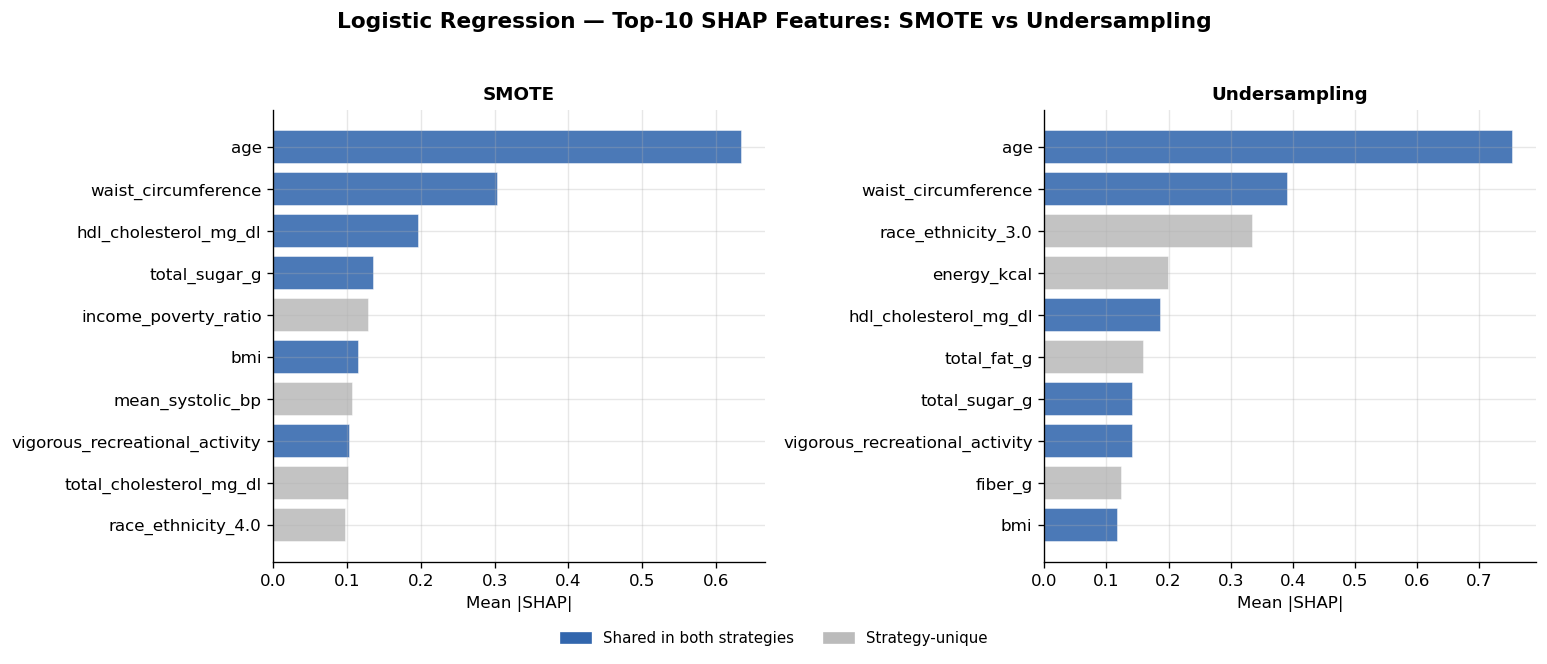

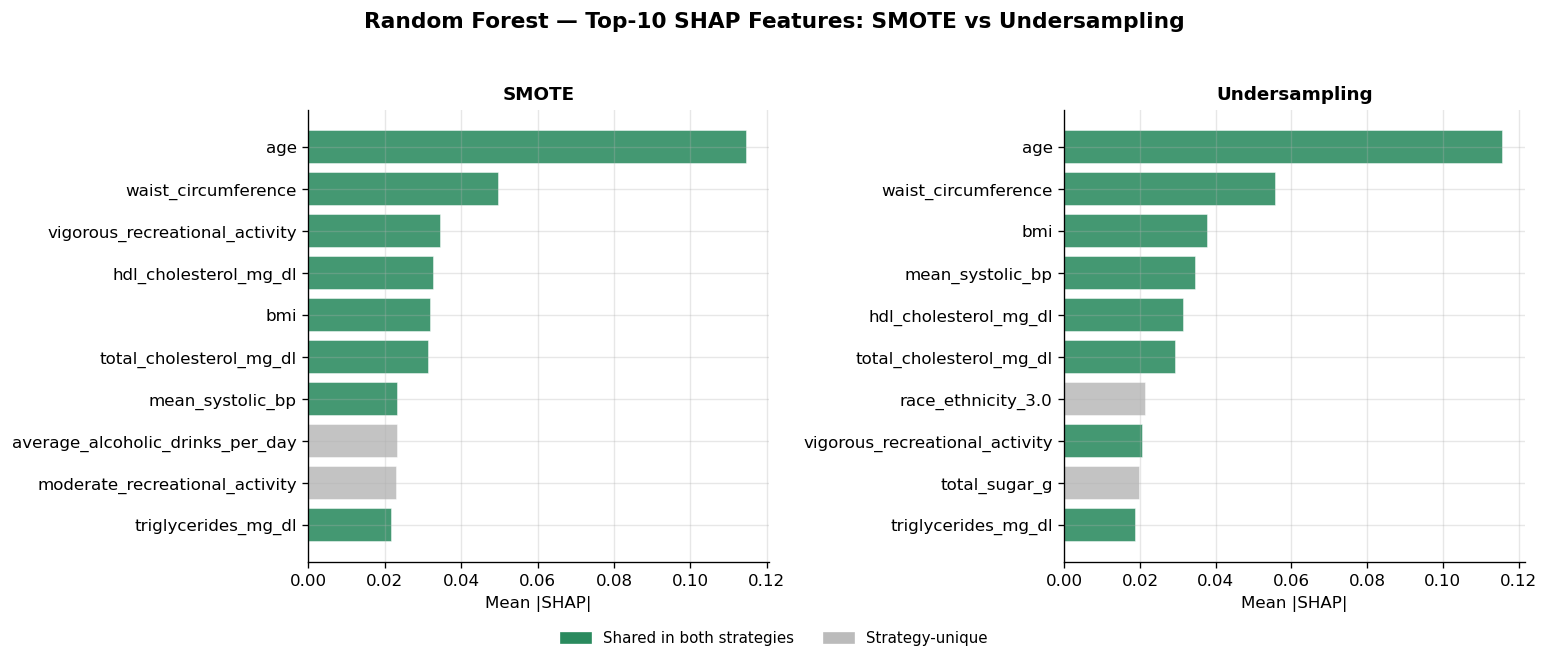

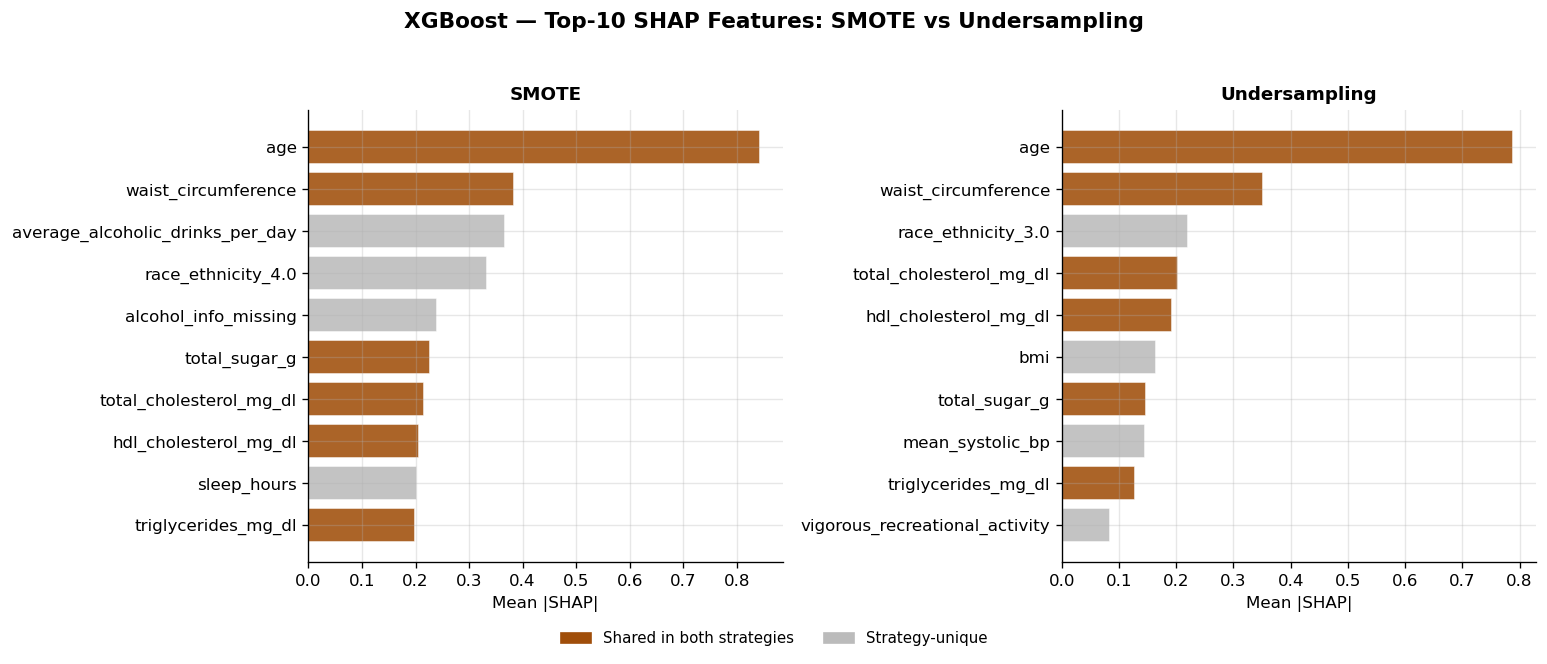

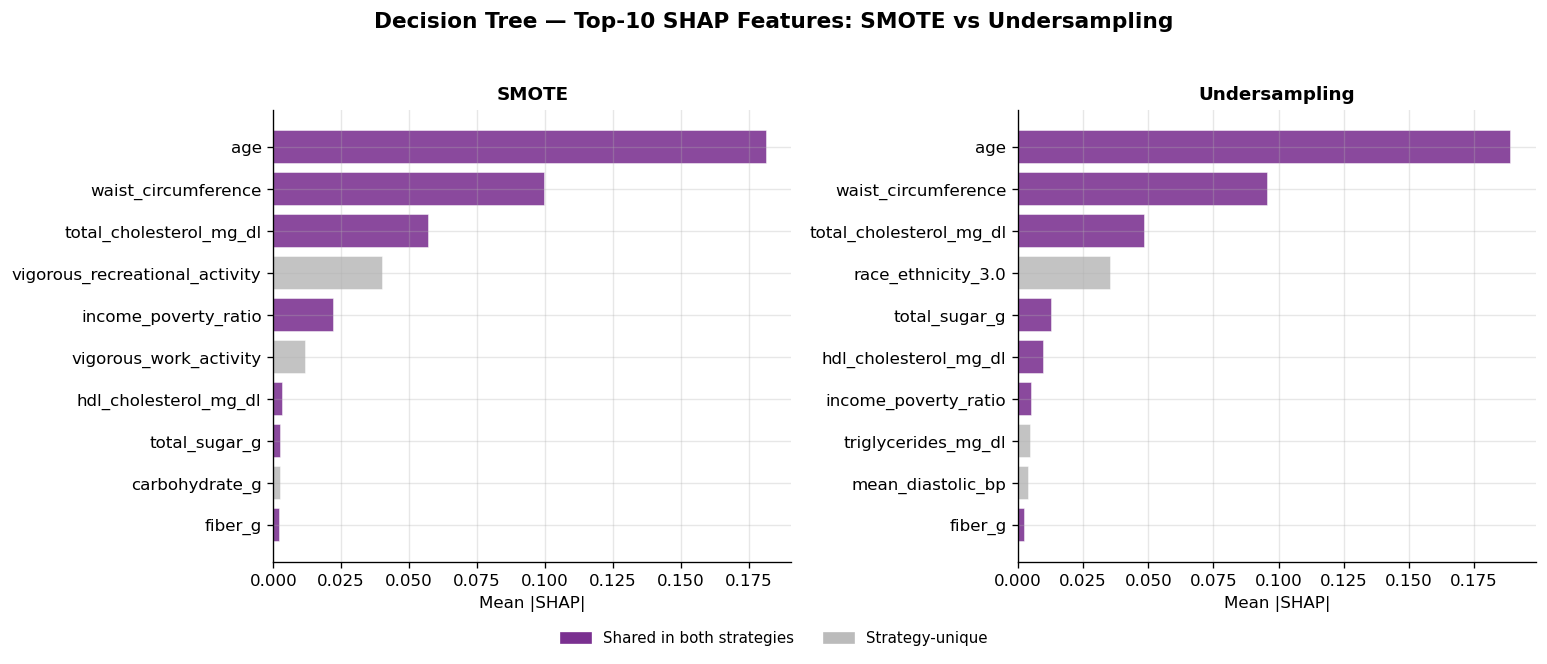

In [18]:
for model in MODELS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    color = MODEL_COLORS[model]

    for ax, strategy in zip(axes, STRATEGIES):
        subset = shap_df[
            (shap_df["Model"] == model) &
            (shap_df["Strategy"] == strategy)
        ].nsmallest(TOP_N, "Rank")

        if subset.empty:
            ax.set_title(f"{strategy}\n(no data)", fontsize=10)
            ax.axis("off")
            continue

        subset = subset.sort_values("Importance", ascending=True)

        # Highlight features that appear in BOTH strategies
        top_smote = get_top_n(shap_df, model, "SMOTE")
        top_under  = get_top_n(shap_df, model, "Undersampling")
        shared     = top_smote & top_under

        bar_colors = [color if f in shared else "#bbbbbb" for f in subset["Feature"]]

        ax.barh(subset["Feature"], subset["Importance"],
                color=bar_colors, edgecolor="white", alpha=0.88)
        ax.set_title(strategy, fontsize=11, fontweight="bold")
        ax.set_xlabel("Mean |SHAP|")

    # Legend
    shared_patch  = mpatches.Patch(color=color,     label="Shared in both strategies")
    unique_patch  = mpatches.Patch(color="#bbbbbb", label="Strategy-unique")
    fig.legend(handles=[shared_patch, unique_patch],
               loc="lower center", ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.05), frameon=False)

    fig.suptitle(f"{model} — Top-{TOP_N} SHAP Features: SMOTE vs Undersampling",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()

    safe_name = model.lower().replace(" ", "_")
    plt.savefig(f"../results/figures/preprocessing_feature_consistency/{safe_name}_top10_comparison.png",
                bbox_inches="tight")
    plt.show()
    print()

---
# Section 2 — Top-10 Overlap per Algorithm

Each bar shows how many of the top 10 SHAP features are shared between SMOTE and Undersampling **for the same algorithm**. A value of 10 means the top-10 list is identical regardless of preprocessing strategy; 0 means no overlap at all.

This directly answers: *does preprocessing strategy change which features a model considers most important?*

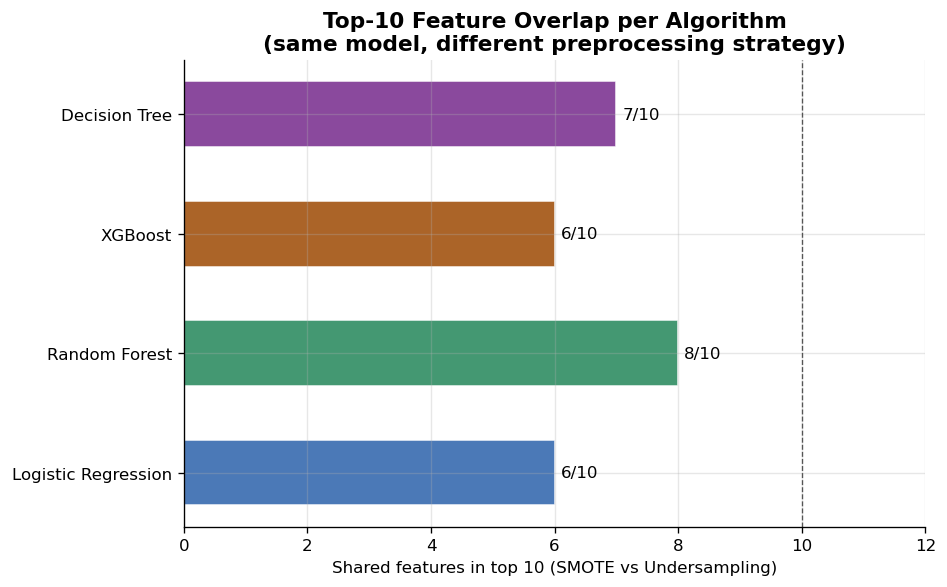

Mean top-10 overlap across algorithms: 6.75


In [19]:
summary_df = compute_all_metrics(shap_df)

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Top-N Overlap"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

# Annotate values
for bar, val in zip(bars, summary_df["Top-N Overlap"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}/{TOP_N}", va="center", ha="left", fontsize=10)

ax.axvline(x=TOP_N, color="#555", linestyle="--", linewidth=0.8, label="Perfect overlap")
ax.set_xlim(0, TOP_N + 2)
ax.set_xlabel(f"Shared features in top {TOP_N} (SMOTE vs Undersampling)", fontsize=10)
ax.set_title(f"Top-{TOP_N} Feature Overlap per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/top10_overlap_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean top-{TOP_N} overlap across algorithms: {summary_df['Top-N Overlap'].mean():.2f}")

---
# Section 3 — Spearman Rank Correlation per Algorithm

Spearman rank correlation is computed over **all** features (not just the top 10), comparing the full rank order produced by SMOTE vs Undersampling **within each algorithm**.

- ρ = 1.0 → identical ranking regardless of preprocessing strategy
- ρ = 0.0 → no correlation between strategies
- ρ < 0.0 → strategies produce inverse orderings

This is a stricter measure than top-10 overlap because it evaluates stability across the entire feature set.

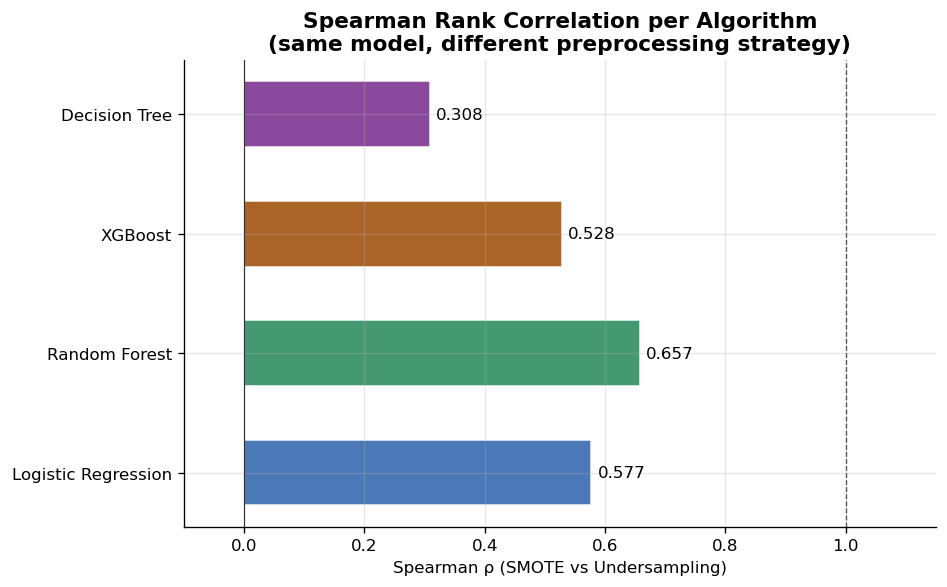

Mean Spearman ρ across algorithms: 0.518
Min: 0.308  Max: 0.657


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Spearman ρ"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

for bar, val in zip(bars, summary_df["Spearman ρ"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=10)

ax.axvline(x=0, color="#333", linewidth=0.7)
ax.axvline(x=1, color="#555", linestyle="--", linewidth=0.8, label="Perfect correlation")
ax.set_xlim(-0.1, 1.15)
ax.set_xlabel("Spearman ρ (SMOTE vs Undersampling)", fontsize=10)
ax.set_title("Spearman Rank Correlation per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")


plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/spearman_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean Spearman ρ across algorithms: {summary_df['Spearman ρ'].mean():.3f}")
print(f"Min: {summary_df['Spearman ρ'].min():.3f}  Max: {summary_df['Spearman ρ'].max():.3f}")

---
# Section 4 — Jaccard Similarity per Algorithm

Jaccard similarity is the ratio of the intersection to the union of the top-10 feature sets produced by SMOTE and Undersampling for the same algorithm.

- J = 1.0 → identical top-10 sets regardless of preprocessing
- J = 0.0 → no features in common in the top 10

Compared to the raw overlap count, Jaccard is normalised to [0, 1] and accounts for the full union — making it easier to compare across experiments with different feature set sizes.

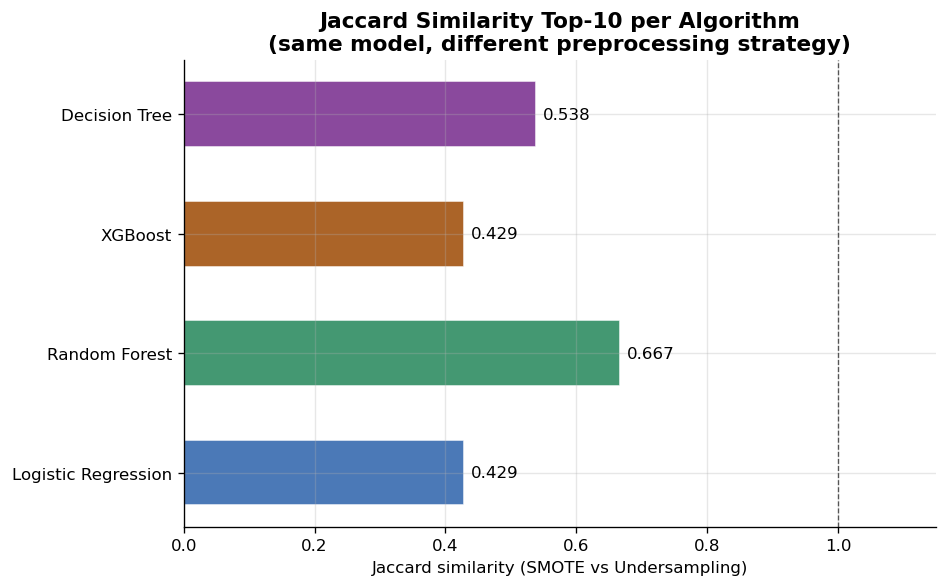

Mean Jaccard similarity across algorithms: 0.516


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Jaccard Similarity"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

for bar, val in zip(bars, summary_df["Jaccard Similarity"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=10)

ax.axvline(x=1, color="#555", linestyle="--", linewidth=0.8, label="Perfect similarity")
ax.set_xlim(0, 1.15)
ax.set_xlabel("Jaccard similarity (SMOTE vs Undersampling)", fontsize=10)
ax.set_title(f"Jaccard Similarity Top-{TOP_N} per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")


plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/jaccard_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean Jaccard similarity across algorithms: {summary_df['Jaccard Similarity'].mean():.3f}")

---
# Section 5 — All Three Metrics Combined (Multi-Metric Overview)

A grouped bar chart that places all three normalised metrics side-by-side for each algorithm. Top-10 overlap is normalised to [0, 1] by dividing by N to make it comparable with Spearman ρ and Jaccard similarity.

This provides a single view for comparing consistency profiles across algorithms: an algorithm that scores high on all three metrics is robust to the choice of preprocessing strategy.

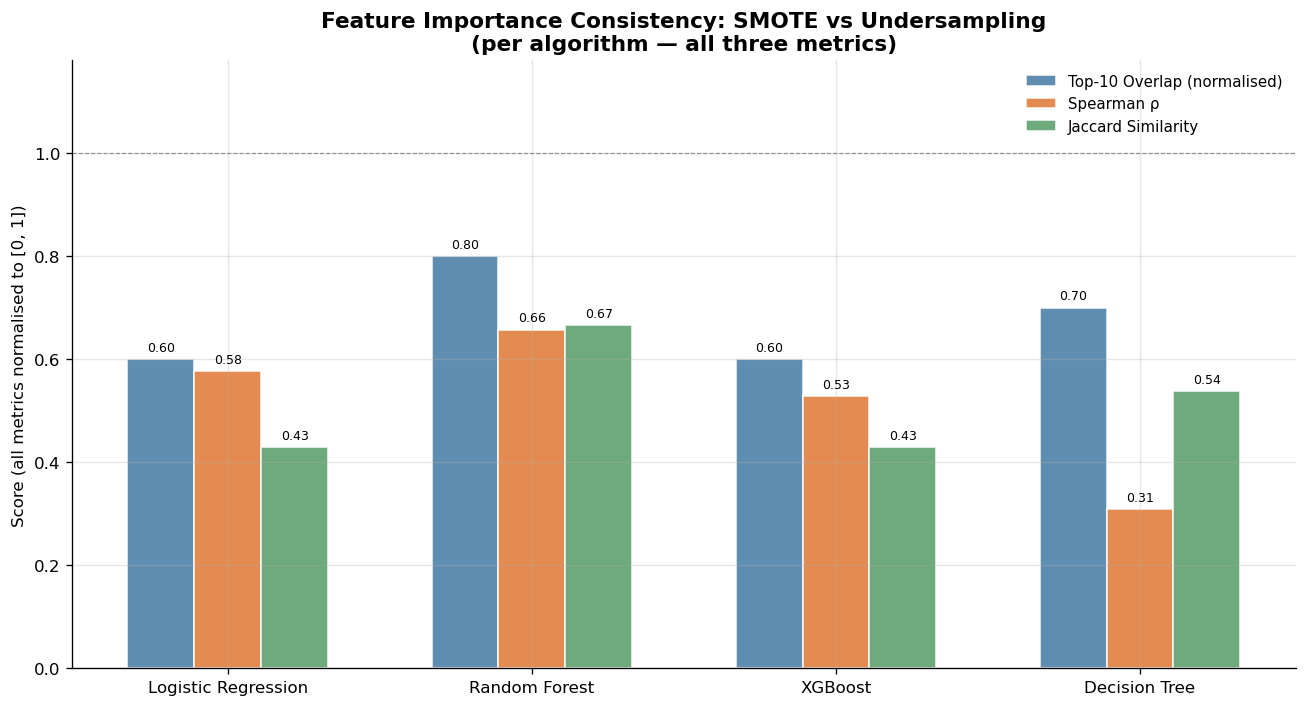

In [22]:
plot_df = summary_df.copy()
plot_df["Top-N Overlap (norm)"] = plot_df["Top-N Overlap"] / TOP_N

metrics       = ["Top-N Overlap (norm)", "Spearman ρ", "Jaccard Similarity"]
metric_labels = [f"Top-{TOP_N} Overlap (normalised)", "Spearman ρ", "Jaccard Similarity"]
metric_colors = ["#4a7fa5", "#e07b39", "#5b9e6b"]

n_models  = len(plot_df)
n_metrics = len(metrics)
x         = np.arange(n_models)
width     = 0.22

fig, ax = plt.subplots(figsize=(11, 6))

for i, (metric, label, mc) in enumerate(zip(metrics, metric_labels, metric_colors)):
    offset = (i - n_metrics / 2 + 0.5) * width
    bars = ax.bar(x + offset, plot_df[metric], width,
                  label=label, color=mc, edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score (all metrics normalised to [0, 1])", fontsize=10)
ax.set_title("Feature Importance Consistency: SMOTE vs Undersampling\n(per algorithm — all three metrics)",
             fontsize=13, fontweight="bold")
ax.axhline(y=1.0, color="#555", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend(fontsize=9, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/multi_metric_overview.png", bbox_inches="tight")
plt.show()

---
# Section 6 — Feature-Level Rank Shift Analysis

For each algorithm, this section computes the rank change of every feature between SMOTE and Undersampling. Features with a large rank shift are highly sensitive to the preprocessing choice; features with a near-zero shift are robust.

The top 15 features by absolute rank shift are shown per algorithm, highlighting which specific features are most affected by the preprocessing strategy.

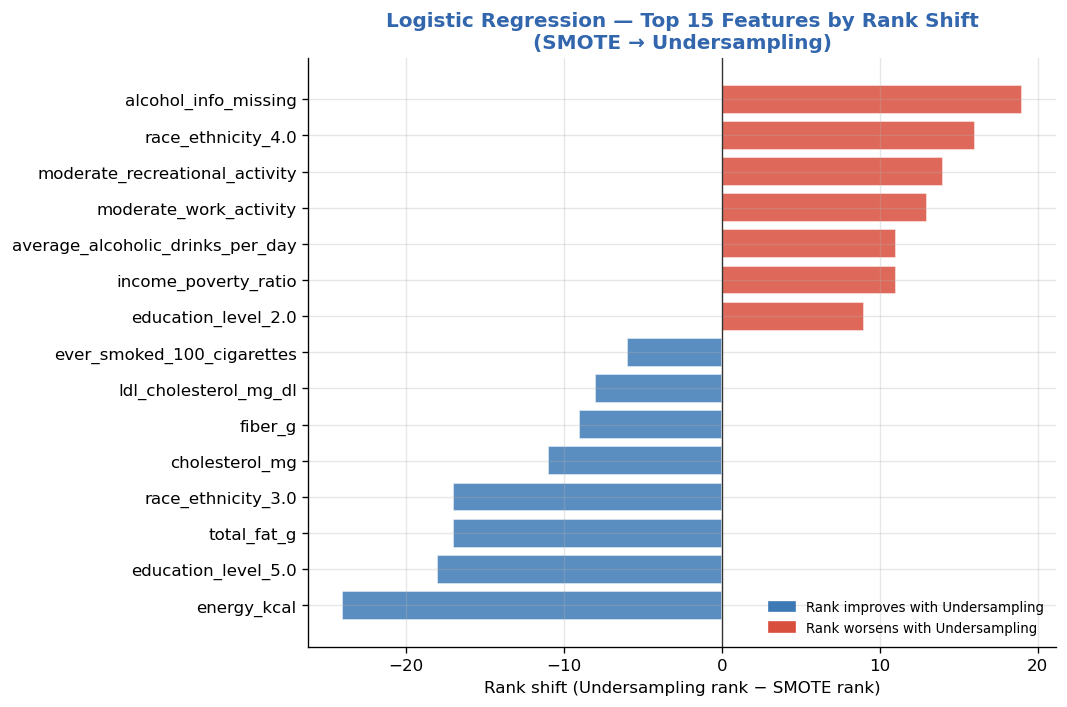

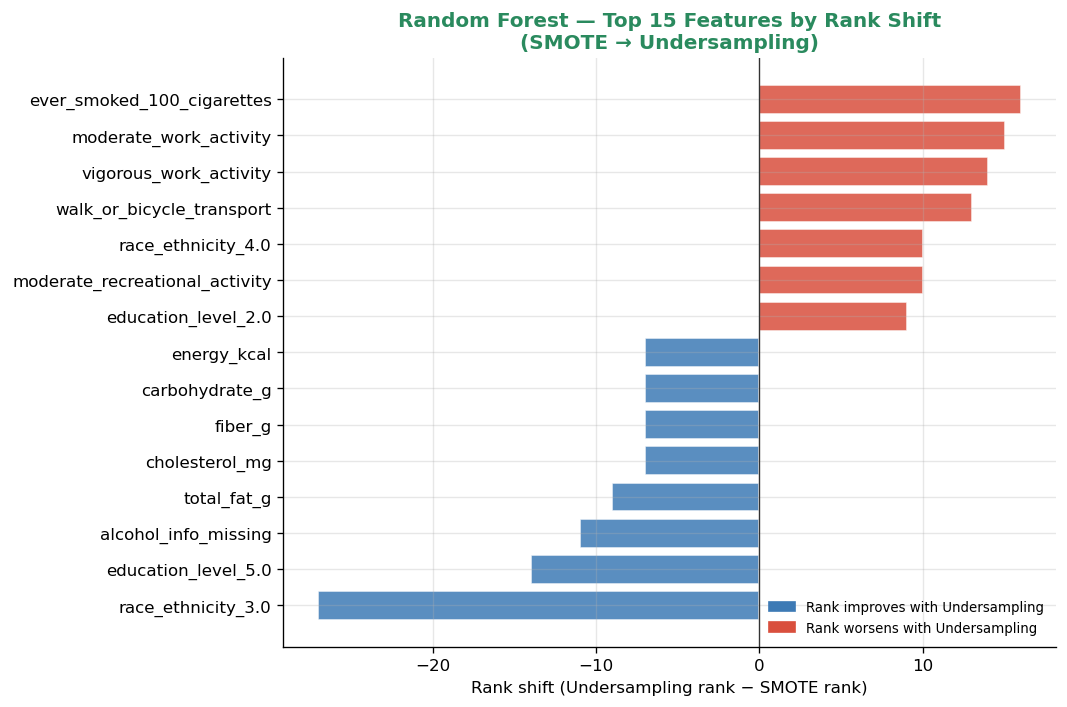

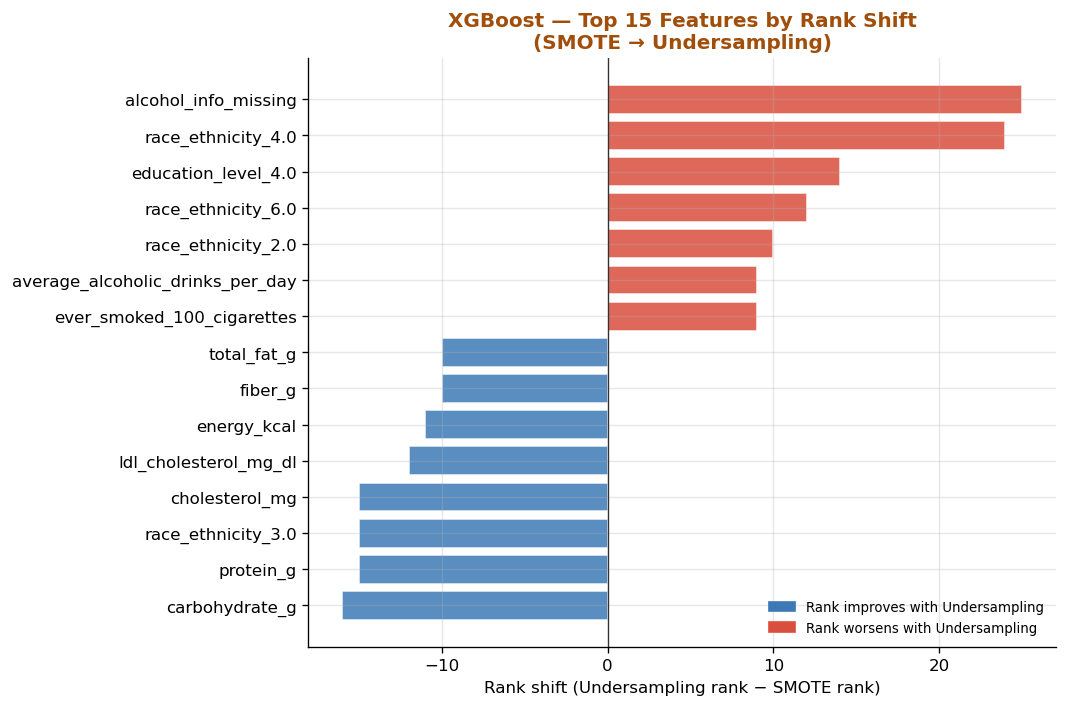

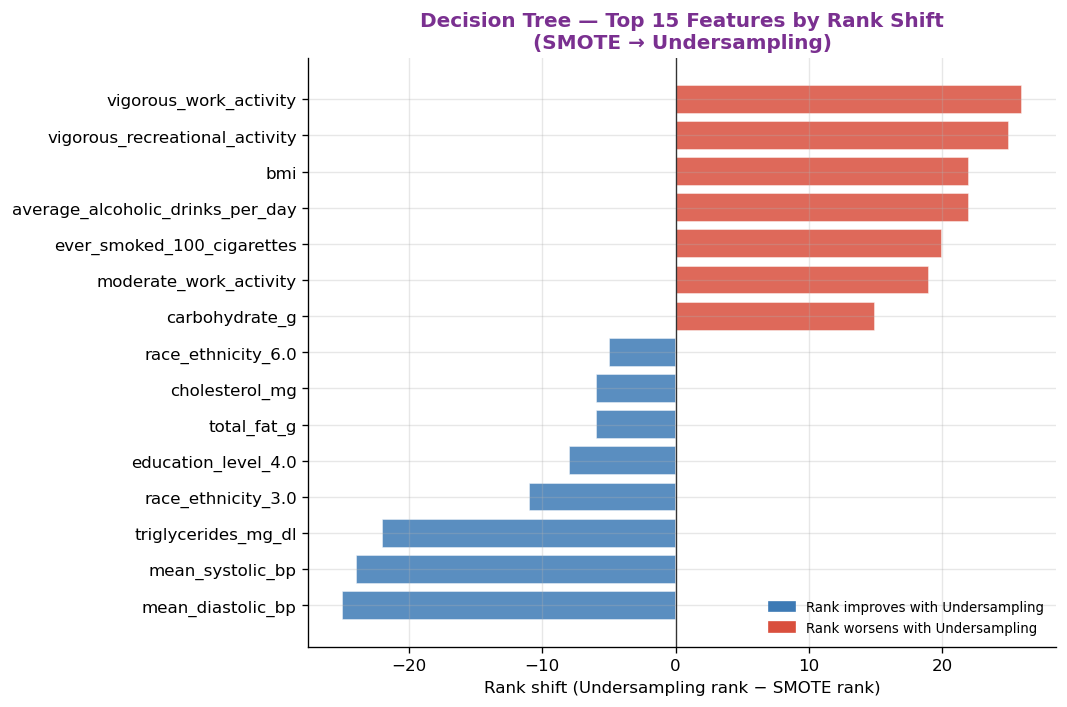

In [23]:
for model in MODELS:
    rank_a = get_full_ranking(shap_df, model, "SMOTE").rename("Rank_SMOTE")
    rank_b = get_full_ranking(shap_df, model, "Undersampling").rename("Rank_Under")

    if rank_a.empty or rank_b.empty:
        print(f"Skipping {model} — missing data for one or both strategies.")
        continue

    merged = pd.concat([rank_a, rank_b], axis=1).dropna()
    merged["Rank Shift"] = merged["Rank_Under"] - merged["Rank_SMOTE"]
    merged["Abs Shift"]  = merged["Rank Shift"].abs()
    merged = merged.sort_values("Abs Shift", ascending=False)

    top15 = merged.head(15).sort_values("Rank Shift")

    color = MODEL_COLORS[model]
    bar_colors = ["#d94f3d" if v > 0 else "#3d7ab5" for v in top15["Rank Shift"]]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top15.index, top15["Rank Shift"],
            color=bar_colors, edgecolor="white", alpha=0.85)
    ax.axvline(x=0, color="#333", linewidth=0.8)

    neg_patch = mpatches.Patch(color="#3d7ab5", label="Rank improves with Undersampling")
    pos_patch = mpatches.Patch(color="#d94f3d", label="Rank worsens with Undersampling")
    ax.legend(handles=[neg_patch, pos_patch], fontsize=8, frameon=False,
              loc="lower right")

    ax.set_xlabel("Rank shift (Undersampling rank − SMOTE rank)", fontsize=10)
    ax.set_title(f"{model} — Top 15 Features by Rank Shift\n(SMOTE → Undersampling)",
                 fontsize=12, fontweight="bold", color=color)

    plt.tight_layout()
    safe_name = model.lower().replace(" ", "_")
    plt.savefig(f"../results/figures/preprocessing_feature_consistency/{safe_name}_rank_shift.png",
                bbox_inches="tight")
    plt.show()
    print()

---
# Section 7 — Summary Table

A single table summarising all three consistency metrics for every algorithm. Rows are sorted by Spearman ρ (descending) so the most preprocessing-stable algorithm appears first.

In [24]:
display_df = summary_df[[
    "Model", "Top-N Overlap", "Spearman ρ", "Jaccard Similarity"
]].copy()

display_df = display_df.sort_values("Spearman ρ", ascending=False).reset_index(drop=True)

display_df["Top-N Overlap"] = display_df["Top-N Overlap"].apply(
    lambda x: f"{int(x)}/{TOP_N}"
)

print(f"Preprocessing Strategy Consistency Summary — SMOTE vs Undersampling (Top-{TOP_N})")
print("="*70)
display(display_df)

print()
print("Overall means (excluding Top-N overlap count):")
print(f"  Spearman ρ:         {summary_df['Spearman ρ'].mean():.3f}")
print(f"  Jaccard Similarity: {summary_df['Jaccard Similarity'].mean():.3f}")
print(f"  Top-N Overlap:      {summary_df['Top-N Overlap'].mean():.1f} / {TOP_N}")

Preprocessing Strategy Consistency Summary — SMOTE vs Undersampling (Top-10)


,Model,Top-N Overlap,Spearman ρ,Jaccard Similarity
0,Random Forest,8/10,0.6574,0.6667
1,Logistic Regression,6/10,0.5773,0.4286
2,XGBoost,6/10,0.5277,0.4286
3,Decision Tree,7/10,0.3084,0.5385



Overall means (excluding Top-N overlap count):
  Spearman ρ:         0.518
  Jaccard Similarity: 0.516
  Top-N Overlap:      6.8 / 10
